In [0]:
import pandas as pd
# Load the feature-engineered dataset
df = pd.read_csv("/Volumes/workspace/default/netflix/feature_engineered_netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_missing,Age_Group_Category,cast_count,content_origin
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm...",0,Teens,1,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,Adults,19,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,Adults,9,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,Adults,1,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,Adults,8,Licensed


Cluster Summary:


cluster,type,numeric_duration,rating_encoded
0,Movie,0.0,9.069346425283829
1,TV Show,0.0,10.050131926121372
2,Movie,0.0,11.242839854780152
3,Movie,0.0,9.505154639175258
4,TV Show,0.0,10.504207573632538


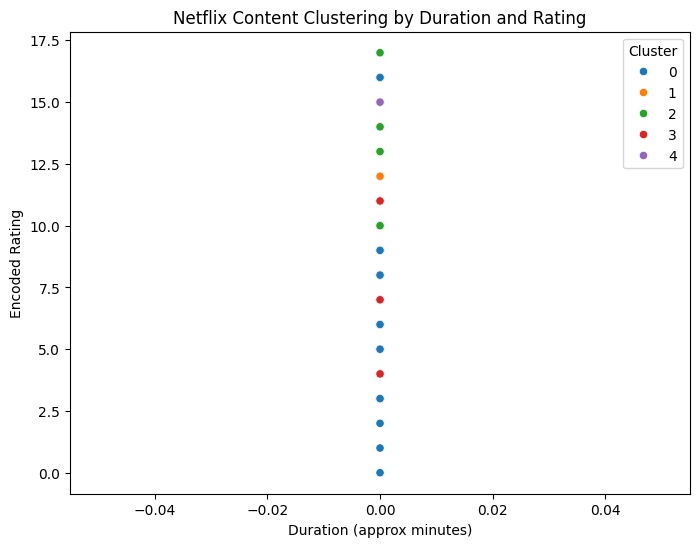

title,listed_in,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90.0,PG-13,2
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2.0,TV-MA,4
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1.0,TV-MA,4
Jailbirds New Orleans,"Docuseries, Reality TV",1.0,TV-MA,2
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2.0,TV-MA,1
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1.0,TV-MA,4
My Little Pony: A New Generation,Children & Family Movies,91.0,PG,0
Sankofa,"Dramas, Independent Movies, International Movies",125.0,TV-MA,3
The Great British Baking Show,"British TV Shows, Reality TV",9.0,TV-14,2
The Starling,"Comedies, Dramas",104.0,PG-13,0


In [0]:
# Netflix Clustering: Grouping Titles by Genre, Duration, and Ratings
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Process 'listed_in' (Genres)
mlb = MultiLabelBinarizer()
genres = df['listed_in'].fillna('').str.split(', ')
genre_features = mlb.fit_transform(genres)

# Step 2: Extract duration numerically
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximation: 1 season = 60 min
        except:
            return 0
    return 0

df['numeric_duration'] = df.apply(extract_duration, axis=1)

# Step 3: Encode 'rating'
le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'].fillna('Unknown'))

# Step 4: Combine features
X = np.hstack([
    genre_features,
    df[['numeric_duration', 'rating_encoded']].values
])

# Step 5: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Step 7: Analyze Clusters
cluster_summary = df.groupby('cluster').agg({
    'type': lambda x: x.value_counts().index[0],
    'numeric_duration': 'mean',
    'rating_encoded': 'mean'
}).reset_index()

print("Cluster Summary:")
display(cluster_summary)

# Step 8: Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='numeric_duration',
    y='rating_encoded',
    hue='cluster',
    palette='tab10'
)
plt.title("Netflix Content Clustering by Duration and Rating")
plt.xlabel("Duration (approx minutes)")
plt.ylabel("Encoded Rating")
plt.legend(title="Cluster")
plt.show()

# Optional: Display a few clustered samples
display(df[['title', 'listed_in', 'duration', 'rating', 'cluster']].head(15))


Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1195
     TV Show       1.00      1.00      1.00       566

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



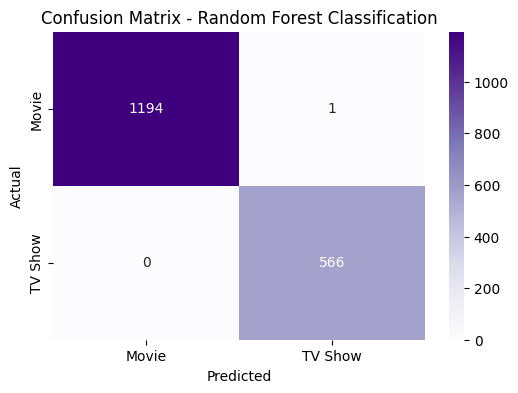

/home/spark-2840709d-01dd-489b-9006-6f/.ipykernel/2476/command-8404372003433737-2962013094:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette="magma")


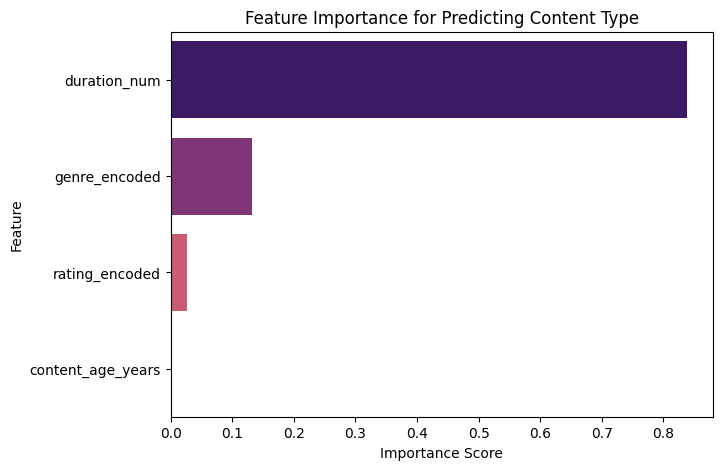

In [0]:
# Classification of Content Type (Movie vs. TV Show)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Copy dataset
df_class = df.copy()

# Feature Preparation

# Extract duration numerically
df_class['duration'] = df_class['duration'].astype(str)
df_class['duration_num'] = df_class['duration'].str.extract(r'(\d+)').astype(float).fillna(0)

# Extract release year to calculate "content age" (assuming dataset has 'release_year')
df_class['content_age_years'] = 2025 - df_class['release_year']

# Simplify genre - use the first listed genre
df_class['primary_genre'] = df_class['listed_in'].str.split(',').str[0].fillna('Unknown')

# Encode categorical columns (rating, primary_genre)
df_class['rating_encoded'] = df_class['rating'].astype('category').cat.codes
df_class['genre_encoded'] = df_class['primary_genre'].astype('category').cat.codes

# Define feature columns and target
feature_cols = ['duration_num', 'rating_encoded', 'genre_encoded', 'content_age_years']
X = df_class[feature_cols]
y = df_class['type'].map({'Movie': 0, 'TV Show': 1})

# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model 
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train, y_train)

# Predictions 
y_pred = clf.predict(X_test)

# Evaluation 
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Movie','TV Show'], yticklabels=['Movie','TV Show'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classification")
plt.show()

# Feature Importance 
feature_importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=feature_importances, y=feature_importances.index, palette="magma")
plt.title("Feature Importance for Predicting Content Type")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
